In [1]:
# imports
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import random
import scipy
from scipy.stats import fisher_exact
from scipy.stats.contingency import odds_ratio
from sklearn import cluster, metrics

from scipy.stats import mannwhitneyu, false_discovery_control, ttest_ind, kstest
from matplotlib.patches import Patch

import cooler 
import cooltools
from matplotlib.colors import LogNorm
import cooltools.lib.plotting
from matplotlib.backends.backend_pdf import PdfPages

from functools import reduce 

import re
#from collections import Counter
import ast 

%cd /home/varshini/uc_analyses/
import utils, matchmaker_functions, loops_txn
%cd /home/varshini/LoopCall_Analysis_Scripts


# plot formatting
plt.rcParams.update({
    "text.usetex": False})
plt.rcParams['svg.fonttype'] = 'none'
plt.rc('pdf',fonttype = 42)
plt.rcParams["ps.useafm"] = True

plt.rcParams['axes.grid'] = False
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.bottom'] = True
plt.rcParams.update({'font.size': 12})

plt.rcParams["legend.frameon"] = False


/home/varshini/uc_analyses
/home/varshini/LoopCall_Analysis_Scripts


/home/varshini/microc_analyses/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:

def search_dist_for_proms(peaks_df, proms_df, dist):
    peaks_df = peaks_df.copy()
    peaks_df['genes'] = [[] for _ in range(len(peaks_df))]
    peaks_df['l2fc'] = [[] for _ in range(len(peaks_df))]
    for peak_idx, peak_row in peaks_df.iterrows():
        peak_chr = peak_row['chr'].split('chr')[1]
        peak_coord = peak_row['coord']

        # Find genes whose TSS is within X of the peak
        nearby_genes = proms_df[
            (proms_df['chromosome_name'] == peak_chr) &
            (abs(proms_df['transcription_start_site'] - peak_coord) <= dist)
        ]

        peaks_df.at[peak_idx, 'genes'] = nearby_genes['external_gene_name'].tolist()
        if 'log2FoldChange' in proms_df.columns:
            peaks_df.at[peak_idx, 'l2fc'] = nearby_genes['log2FoldChange'].mean()
            
    peaks_df['num_genes'] = peaks_df['genes'].apply(len)
    
    
    return peaks_df

    
def assign_proms_to_mm(peaks_df, proms_df, min_dist, max_dist):
    peaks = peaks_df.copy()
    proms = proms_df.copy()
    
    # normalize chromosome naming
    peaks["chromosome_name"] = peaks["chr"].str.replace("chr", "", regex=False)

    # output columns
    proms["mm_quant"] = np.nan
    proms["dist"] = np.nan
    proms["triangle_fc"] = np.nan
    proms["mm_peak"] = np.nan

    for chrom, proms_sub in proms.groupby("chromosome_name"):
        peaks_sub = peaks[peaks["chromosome_name"] == chrom]
        if peaks_sub.empty:
            continue

        # sort peaks once
        peaks_sub = peaks_sub.sort_values("coord")
        peak_coords = peaks_sub["coord"].values
        peak_quants = peaks_sub["quant"].values
        tri_scores = peaks_sub["triangle_fc"].values
        # promoter coords
        prom_coords = proms_sub["transcription_start_site"].values

        # find insertion positions
        idxs = np.searchsorted(peak_coords, prom_coords)

        # clip to valid range
        idxs_left = np.clip(idxs - 1, 0, len(peak_coords) - 1)
        idxs_right = np.clip(idxs, 0, len(peak_coords) - 1)

        # compute distances to neighbors
        d_left = np.abs(prom_coords - peak_coords[idxs_left])
        d_right = np.abs(prom_coords - peak_coords[idxs_right])

        # choose nearest
        use_left = d_left <= d_right
        nearest_idxs = np.where(use_left, idxs_left, idxs_right)
        d = np.minimum(d_left, d_right)

        valid = (d <= max_dist) & (d >= min_dist)

        proms.loc[proms_sub.index[valid], "mm_quant"] = peak_quants[nearest_idxs[valid]]
        proms.loc[proms_sub.index[valid], "dist"] = d[valid]
        proms.loc[proms_sub.index[valid], "triangle_fc"] = tri_scores[nearest_idxs[valid]]
        proms.loc[proms_sub.index[valid], "mm_peak"] = peak_coords[nearest_idxs[valid]]

    return proms

In [3]:
# loading 

basedir_genes = "/mnt/md0/varshini/Analysis/Blood/complete_analyses/gene_sets_expr"
# 1. p3 markers
p3_markers = pd.read_csv(os.path.join(basedir_genes, "findmarkers_p3_ebm.tsv"), sep="\t")
p3_markers['gene'] = p3_markers.index
p3_markers.reset_index(drop=True, inplace=True)

ebm_markers = pd.read_csv(os.path.join(basedir_genes, "findmarkers_ebm.tsv"), sep="\t")
ebm_markers['gene'] = ebm_markers.index
ebm_markers.reset_index(drop=True, inplace=True)

# 3. accessible promoters
atac_proms = pd.read_csv("/mnt/md0/varshini/Analysis/Blood/complete_analyses/gene_sets_expr/promoters_accessible_all.bed",
                        sep="\t",
                        names=['chr','start','end','accession','alt','strand']).drop(['alt', 'strand'],axis=1).drop_duplicates()

# 4. erythroid-differentially accessible 
diff_proms = pd.read_csv("/mnt/md0/varshini/Analysis/Blood/complete_analyses/gene_sets_expr/promoters_eACRs_all.bed",
                        sep="\t",
                        names=['chr','start','end','accession','alt','strand']).drop('alt',axis=1).drop_duplicates()

# 5. lookup table 
lut = pd.read_csv("/mnt/md0/varshini/Analysis/Adipose/GeneExp/tss_hg38_all_types.tsv",
                 sep="\t").drop_duplicates(subset=['external_gene_name','refseq_id'])

p3_marker_gex = pd.read_csv(os.path.join(basedir_genes, "findmarkers_p3_norm_counts.tsv"),
                           sep="\t")
p31_dge_gex = pd.read_csv(os.path.join(basedir_genes, "p31_dge_norm_counts.tsv"),
                           sep="\t")
all_gex = pd.read_csv(os.path.join(basedir_genes, "all_bulk_expr.tsv"),
                           sep="\t")


/tmp/ipykernel_1629482/1660016833.py:24: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  lut = pd.read_csv("/mnt/md0/varshini/Analysis/Adipose/GeneExp/tss_hg38_all_types.tsv",


In [4]:
len(all_gex[all_gex['P3']> np.percentile(all_gex['P3'], 95)])

1829

In [5]:
p3_markers

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,gene
0,0.000000,4.840846,0.561,0.060,0.000000,TSPO2
1,0.000000,3.467161,0.637,0.147,0.000000,TNS1
2,0.000000,2.967086,0.767,0.293,0.000000,GYPE
3,0.000000,4.052142,0.528,0.055,0.000000,AC100835.2
4,0.000000,3.370155,0.988,0.521,0.000000,SLC4A1
...,...,...,...,...,...,...
1061,0.000001,0.177942,0.039,0.064,0.042302,AL161443.1
1062,0.000001,0.230206,0.025,0.045,0.042987,ARHGEF10
1063,0.000001,0.108911,0.161,0.214,0.044880,RORA-AS1
1064,0.000001,0.388521,0.051,0.079,0.045862,AC104316.1


In [77]:
np.percentile(all_gex[all_gex['P3']>0]['P3'], 75)

0.1491513990350245

In [68]:
all_gex[all_gex['P3']>0]

,P1,P2,P3,EoBasoMast Precursor,CD14 Mono,Megakaryocyte Precursor,Early GMP,GMP-Mono,LMPP,HSC,cDC2,Stromal,Pre-cDC,Cycling Progenitor,GMP-Neut,MPP-MyLy,Pre-pDC,MPP-MkEry,Early ProMono
MIR1302-2HG,0.000466,0.000089,0.000265,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0
OR4F5,0.000000,0.000000,0.000794,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0
AL627309.1,0.009739,0.013377,0.022256,0.005400,0.000000,0.035555,0.041433,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0
AL627309.3,0.000466,0.000178,0.000794,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0
AL627309.5,0.015261,0.013201,0.021479,0.005400,0.000000,0.035555,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.132032,0.000000,0.0,0.000000,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AL592183.1,0.307996,0.239190,0.190809,0.436225,0.508603,0.211287,0.700760,0.448654,0.455377,0.0,0.967223,0.323078,0.353073,0.565978,0.0,0.759125,0.261876,0.0,0.0
AC240274.1,0.010661,0.004893,0.001587,0.025657,0.000000,0.009008,0.041433,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0
AC004556.3,0.000932,0.000535,0.000265,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0
AC136616.1,0.000000,0.000089,0.000265,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0


In [6]:
atac_proms_dedup = utils.clean_chroms(atac_proms.merge(lut, how='left', left_on='accession', right_on='refseq_id'))
atac_proms_dedup.drop_duplicates(subset='external_gene_name', inplace=True)
atac_proms_dedup.sort_values(by=['chr','start','end'], inplace=True)

diff_proms_dedup = utils.clean_chroms(diff_proms.merge(lut, how='left', left_on='accession', right_on='refseq_id'))
diff_proms_dedup.drop_duplicates(subset='external_gene_name', inplace=True)
diff_proms_dedup.sort_values(by=['chr','start','end'], inplace=True)

all_gex_expr = all_gex[(all_gex['P1']>1e-1)|(all_gex['P2']>1e-1)|(all_gex['P3']>1e-1)]
all_gex_expr_P3 = all_gex[all_gex['P3']>1e-1] 
all_gex_low = all_gex[(all_gex['P3']<1e-1)]


In [7]:
atac_proms_dedup.columns

Index(['chr', 'start', 'end', 'accession', 'ensembl_gene_id',
       'external_gene_name', 'chromosome_name', 'strand',
       'transcription_start_site', 'gene_biotype', 'transcript_length',
       'refseq_mrna', 'refseq_ncrna', 'tss_start', 'tss_end', 'refseq_id'],
      dtype='object')

In [8]:
p3_markers_tss = p3_markers.merge(lut.drop_duplicates('external_gene_name'), how='left', left_on='gene', right_on='external_gene_name')
p3_markers_tss.dropna(subset='transcription_start_site', inplace=True)
p3_markers_tss.rename({'avg_log2FC':'log2FoldChange'}, axis=1, inplace=True)


ebm_markers_tss = ebm_markers.merge(lut.drop_duplicates('external_gene_name'), how='left', left_on='gene', right_on='external_gene_name')
ebm_markers_tss.dropna(subset='transcription_start_site', inplace=True)
ebm_markers_tss.rename({'avg_log2FC':'log2FoldChange'}, axis=1, inplace=True)


all_gex_expr_P3['gene']=all_gex_expr_P3.index
all_gex_expr['gene']=all_gex_expr.index
all_gex_low['gene']=all_gex_low.index




In [9]:
all_gex_tss = all_gex_expr.merge(lut.drop_duplicates('external_gene_name'), how='left', left_on='gene', right_on='external_gene_name')
all_gex_tss.dropna(subset='transcription_start_site', inplace=True)

all_gex_P3_tss = all_gex_expr_P3.merge(lut.drop_duplicates('external_gene_name'), how='left', left_on='gene', right_on='external_gene_name')
all_gex_P3_tss.dropna(subset='transcription_start_site', inplace=True)

all_gex_low_tss = all_gex_low.merge(lut.drop_duplicates('external_gene_name'), how='left', left_on='gene', right_on='external_gene_name')
all_gex_low_tss.dropna(subset='transcription_start_site', inplace=True)

In [10]:
## identify marker genes near matchmakers as in Fig. 4B (so exclude those near other clusters)

In [11]:
# read clustered matchmaker file 

mm="/mnt/md0/varshini/Analysis/Blood/complete_analyses/matchmakers/erythroid_tf_acrs_all_enhancernotpromoternotctcf_100kb_merge10.0kb_clus.bed"
mm_df = pd.read_csv(mm, sep="\t")
mm_df['triangle_fc'] = mm_df['triangle_score_P3']/mm_df['triangle_score_P1']


In [12]:
ls_fname = 'able_scores_125kb_q0.012000bp_wavg.tsv'
loop_strengths = pd.read_csv(os.path.join( '/mnt/md0/varshini/Analysis/Blood/complete_analyses/loops_anchors/', ls_fname), sep='\t',
                            names=['chr1','start1','end1','chr2','start2','end2','prob',
                                    'strength_P1','strength_P2', 'strength_P3'])
loop_strengths['anchor1']=loop_strengths[['start1','end1']].mean(axis=1)
loop_strengths['anchor2']=loop_strengths[['start2','end2']].mean(axis=1)


In [13]:
fname = 'merged_calls_125kb_q0.01_classes_new.txt'
loop_classes = pd.read_csv(os.path.join('/mnt/md0/varshini/Analysis/Blood/complete_analyses/loops_anchors/', fname), sep='\t')
loop_classes[['start1','start2']] = loop_classes[['start1','start2']] - 1

cols_drop = ['anchor1', 'anchor2', 'anchor1_annotation', 
             'anchor2_annotation','annotation1','annotation2',
            'NA.','strand1','strand2', 'width1','width2']
    
for c in cols_drop:
    if c in loop_classes.columns:
        loop_classes.drop(c,axis=1, inplace=True)
loop_classes.columns = ['chr1','start1','end1','chr2','start2','end2','class']

In [14]:
pval = 0.01
pct1 = 0.1
l2fc = 0.25

mindist=0
dist=100000

In [15]:
genes_to_mms = assign_proms_to_mm(mm_df, p3_markers_tss[(p3_markers_tss['p_val_adj']<pval)&
                                                       (p3_markers_tss['pct.1']>pct1)&
                                                       (p3_markers_tss['log2FoldChange']>l2fc)], mindist, dist)
genes_to_mms_control = assign_proms_to_mm(mm_df, ebm_markers_tss[(ebm_markers_tss['p_val_adj']<pval)&
                                                                (ebm_markers_tss['pct.1']>pct1)&
                                                                (ebm_markers_tss['log2FoldChange']>l2fc)], mindist, dist)
atac_to_mms = assign_proms_to_mm(mm_df, atac_proms_dedup, mindist, dist)

gex_to_mms = assign_proms_to_mm(mm_df, all_gex_tss, mindist, dist) 
gex_to_mms_low = assign_proms_to_mm(mm_df, all_gex_low_tss, mindist, dist) 

gex_to_mms_P3 = assign_proms_to_mm(mm_df, all_gex_P3_tss, mindist, dist) 



In [16]:
savedir="/mnt/md0/varshini/Analysis/Blood/figs_v4/fig4"

if not os.path.exists(savedir):
    os.mkdir(savedir)

In [41]:
dataset = gex_to_mms_P3
dataset_name = "p3_expressed"

In [42]:
dataset.dropna(subset-'mm_quant', inplace=True)
dataset['mm_annotation'] = np.where(dataset['mm_quant'].isin([2, 3]),
    "matchmaker",
    "not_matchmaker",
)

23059.0
34093.25


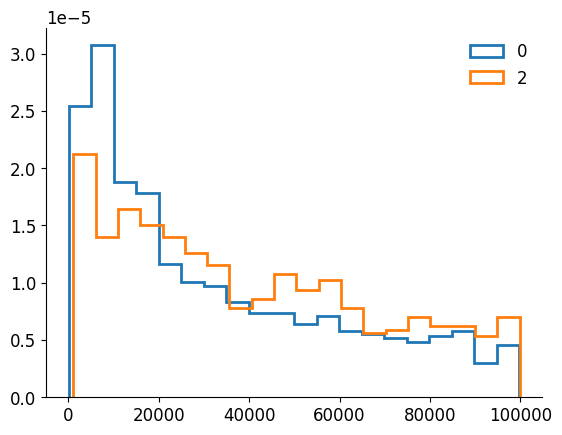

In [43]:
## plot the distance distribution 
for quant in ([0, 1], [2,3]):
    plt.hist(dataset[dataset['mm_quant'].isin(quant)]['dist'].dropna(), bins=20, fill=False,
             histtype='step', label=quant, density=True, cumulative=False, linewidth=2)
    print(dataset[dataset['mm_quant'].isin(quant)]['dist'].median())
plt.legend()
#plt.savefig(os.path.join(savedir, f"{dataset_name}_distance_hist.svg"))

plt.show()

In [44]:
genes_to_mms['dist'].min()

1227.5

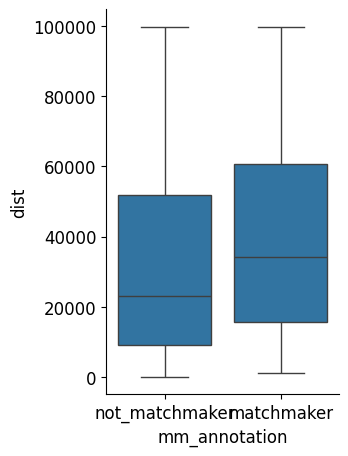

In [45]:
plt.figure(figsize=(3,5))
sns.boxplot(dataset, x='mm_annotation', y='dist', showfliers=False)
#plt.savefig(os.path.join(savedir, f"{dataset_name}_distance_box.svg"))
plt.show()



In [46]:
gex_to_mms_low

,P1,P2,P3,EoBasoMast Precursor,CD14 Mono,Megakaryocyte Precursor,Early GMP,GMP-Mono,LMPP,HSC,...,transcript_length,refseq_mrna,refseq_ncrna,tss_start,tss_end,refseq_id,mm_quant,dist,triangle_fc,mm_peak
1,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.000000,0.0,...,1373.0,NaN,NR_026818,36266.0,36267.0,NR_026818,NaN,NaN,NaN,NaN
2,0.000000,0.000000,0.000794,0.000000,0.00000,0.000000,0.000000,0.0,0.000000,0.0,...,2618.0,NM_001422116,NaN,65418.0,65419.0,NM_001422116,NaN,NaN,NaN,NaN
10,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.000000,0.0,...,939.0,NM_001005221,NaN,451677.0,451678.0,NM_001005221,NaN,NaN,NaN,NaN
12,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.000000,0.0,...,939.0,NM_001005277,NaN,686653.0,686654.0,NM_001005277,NaN,NaN,NaN,NaN
14,0.092941,0.093012,0.069049,0.134552,0.11381,0.078292,0.226196,0.0,0.000000,0.0,...,1291.0,NaN,NR_187359,778811.0,778812.0,NR_187359,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29314,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.000000,0.0,...,1707.0,NM_001007523,NaN,155382094.0,155382095.0,NM_001007523,NaN,NaN,NaN,NaN
29315,0.000000,0.000178,0.000529,0.000000,0.00000,0.000000,0.000000,0.0,0.000000,0.0,...,1707.0,NM_001007524,NaN,155458619.0,155458620.0,NM_001007524,NaN,NaN,NaN,NaN
29318,0.006040,0.004005,0.001587,0.007552,0.00000,0.000000,0.000000,0.0,0.000000,0.0,...,8931.0,NM_001394354,NaN,155612585.0,155612586.0,NM_001394354,NaN,NaN,NaN,NaN
29319,0.194606,0.035223,0.001059,0.356092,0.00000,0.315539,0.000000,0.0,0.253389,0.0,...,2038.0,NM_002186,NaN,155997695.0,155997696.0,NM_002186,NaN,NaN,NaN,NaN


In [47]:
loop_classes

,chr1,start1,end1,chr2,start2,end2,class
0,chr1,5990000,5995000,chr1,6197000,6202000,P-P
1,chr1,5991000,5996000,chr1,6024000,6029000,P-P
2,chr1,6039000,6044000,chr1,6242000,6247000,P-P
3,chr1,6050000,6055000,chr1,6242000,6247000,P-Null
4,chr1,6107000,6112000,chr1,6169000,6174000,CTCF-Null
...,...,...,...,...,...,...,...
63724,chrX,152950000,152955000,chrX,154310000,154315000,Null-Null
63725,chrX,153545000,153550000,chrX,154535000,154540000,P-Null
63726,chrX,153740000,153745000,chrX,154540000,154545000,P-Null
63727,chrX,155640000,155645000,chrX,155955000,155960000,Null-Null


In [48]:
dataset['chr'] = 'chr' + dataset['chromosome_name'].astype(str)


In [49]:
dataset.columns

Index(['P1', 'P2', 'P3', 'EoBasoMast Precursor', 'CD14 Mono',
       'Megakaryocyte Precursor', 'Early GMP', 'GMP-Mono', 'LMPP', 'HSC',
       'cDC2', 'Stromal', 'Pre-cDC', 'Cycling Progenitor', 'GMP-Neut',
       'MPP-MyLy', 'Pre-pDC', 'MPP-MkEry', 'Early ProMono', 'gene',
       'ensembl_gene_id', 'external_gene_name', 'chromosome_name', 'strand',
       'transcription_start_site', 'gene_biotype', 'transcript_length',
       'refseq_mrna', 'refseq_ncrna', 'tss_start', 'tss_end', 'refseq_id',
       'mm_quant', 'dist', 'triangle_fc', 'mm_peak', 'mm_annotation', 'chr'],
      dtype='object')

In [50]:
dataset.rename({'tss_start':'start','tss_end':'end', 'external_gene_name':'hgnc_symbol'}, axis=1, inplace=True)

# if 'start' in dataset.columns:
#     dataset.drop(['start','end'], inplace=True)
    
    
plus = dataset["strand"] == "+"
dataset["start"] = np.where(
    plus,
    dataset["transcription_start_site"] - 2000,
    dataset["transcription_start_site"] - 1000,
)

dataset["end"] = np.where(
    plus,
    dataset["transcription_start_site"] + 1000,
    dataset["transcription_start_site"] + 2000,
)

In [51]:
# now i have the promoters of the test and control genes. 

def get_promoter_loops(df_clustered, loops, how='best', dedup_by_gene=True):
    promloops = []

    # slow version but not slow enough that i can be bothered to fix it
    for i, row in df_clustered.iterrows():
        out = assign_gene_to_loops(row, loops, how)
        promloops.append(out)
        if len(promloops) % 5000 == 0:
            print(len(promloops))
    identified_promoter_loops = pd.concat(promloops, axis=0)
    identified_promoter_loops = identified_promoter_loops.set_index(identified_promoter_loops['ensembl_gene_id'])

    # if a gene has multiple "promoters" that belong to the same loop, they're probably alt TSS that are super close
    if dedup_by_gene:
        if 'Cluster' in identified_promoter_loops.columns:
            identified_promoter_loops.drop_duplicates(subset=['gene_name', 'chr1', 'start1', 'start2', 'Cluster'], inplace=True)
        else:
            identified_promoter_loops.drop_duplicates(subset=['gene_name', 'chr1', 'start1', 'start2'], inplace=True)
    return identified_promoter_loops


# search gene for loop matches
# if how = best, keep the anchor with the largest overlap (only one anchor allowed per promoter)
# if how = all, keep any anchor that overlaps the promoter
def assign_gene_to_loops(gene_row, loop_df, how='best'):
    assert how in ["best", "all"], "argument 'how' must be one of 'best', 'all'"

    if gene_row['strand'] == '-':
        TSS = gene_row['start'] + 1000  # 1000 bp downstream
    else:
        TSS = gene_row['start'] + 2000  # 2000 bp upstream
    candidate_loops = loop_df[(loop_df['chr1'] == gene_row['chr']) &
                              ((loop_df['start1'].between(gene_row['start'], gene_row['end'])) |
                               (loop_df['end1'].between(gene_row['start'], gene_row['end'])) |
                               (loop_df['start2'].between(gene_row['start'], gene_row['end'])) |
                               (loop_df['end2'].between(gene_row['start'], gene_row['end'])))]
    loops_start = candidate_loops.loc[:, 'start1':'end1'].mean(axis=1)
    loops_end = candidate_loops.loc[:, 'start2':'end2'].mean(axis=1)

    candidate_loops.loc[:, 'diff_a1'] = np.abs(loops_start.loc[:] - TSS)
    candidate_loops.loc[:, 'diff_a2'] = np.abs(loops_end.loc[:] - TSS)
    candidate_loops.loc[:, 'min_diff'] = candidate_loops.loc[:, ['diff_a1', 'diff_a2']].min(axis=1)
    candidate_loops["promoter"] = np.where(
        candidate_loops["min_diff"] == candidate_loops["diff_a1"],
        "anchor1",
        "anchor2",
    )

    candidate_loops['ensembl_gene_id'] = gene_row['ensembl_gene_id']
    candidate_loops['gene_name'] = gene_row['hgnc_symbol']
    candidate_loops['tss'] = TSS

    if 'Cluster' in gene_row:
        candidate_loops['Cluster'] = gene_row['Cluster']

    if candidate_loops is not None:
        if how == 'all':
            return candidate_loops
        elif how == 'best':
            match = candidate_loops[candidate_loops['min_diff'] == candidate_loops['min_diff'].min()]
            return match
        else:
            return -1
    else:
        return -1
    
def get_prom_loop_strengths_no_degs(proms, loops, loop_strengths, writepath=None, how='best'):
    proms_trimmed = utils.clean_chroms(proms)
    proms_trimmed.index = proms_trimmed['ensembl_gene_id']
    
    ploops = get_promoter_loops(proms_trimmed, loops, how=how)
    prom_loop_strengths = ploops.merge(loop_strengths, how='left',
                                           on=['chr1', 'start1', 'end1', 'chr2', 'start2', 'end2'])
    if writepath is not None:
        prom_loop_strengths.to_csv(writepath, sep='\t', index=False)

    return prom_loop_strengths




In [52]:
dataset.dropna(subset='mm_quant', inplace=True)

In [53]:
prom_loop_strengths = get_prom_loop_strengths_no_degs(dataset, loop_classes, loop_strengths, None, how='all')

In [54]:
prom_loop_strengths.columns

Index(['chr1', 'start1', 'end1', 'chr2', 'start2', 'end2', 'class', 'diff_a1',
       'diff_a2', 'min_diff', 'promoter', 'ensembl_gene_id', 'gene_name',
       'tss', 'prob', 'strength_P1', 'strength_P2', 'strength_P3', 'anchor1',
       'anchor2'],
      dtype='object')

In [55]:
# option 1: do promoter loop matching using my existing function, then get AbLE scores 
pls_mm = prom_loop_strengths.merge(dataset, how='left', on='ensembl_gene_id')

In [56]:
pls_mm['mm_quant'].min()

0.0

In [57]:
pls_mm.columns

Index(['chr1', 'start1', 'end1', 'chr2', 'start2', 'end2', 'class', 'diff_a1',
       'diff_a2', 'min_diff', 'promoter', 'ensembl_gene_id', 'gene_name',
       'tss', 'prob', 'strength_P1', 'strength_P2', 'strength_P3', 'anchor1',
       'anchor2', 'P1', 'P2', 'P3', 'EoBasoMast Precursor', 'CD14 Mono',
       'Megakaryocyte Precursor', 'Early GMP', 'GMP-Mono', 'LMPP', 'HSC',
       'cDC2', 'Stromal', 'Pre-cDC', 'Cycling Progenitor', 'GMP-Neut',
       'MPP-MyLy', 'Pre-pDC', 'MPP-MkEry', 'Early ProMono', 'gene',
       'hgnc_symbol', 'chromosome_name', 'strand', 'transcription_start_site',
       'gene_biotype', 'transcript_length', 'refseq_mrna', 'refseq_ncrna',
       'start', 'end', 'refseq_id', 'mm_quant', 'dist', 'triangle_fc',
       'mm_peak', 'mm_annotation', 'chr'],
      dtype='object')

In [58]:
# exclude anchors that could represent loops with the matchmaker element itself
touches_mm = (
    ((pls_mm["start1"] - pls_mm["mm_peak"]).abs() <= 5_000) |
    ((pls_mm["end1"]   - pls_mm["mm_peak"]).abs() <= 5_000) |
    ((pls_mm["start2"] - pls_mm["mm_peak"]).abs() <= 5_000) |
    ((pls_mm["end2"]   - pls_mm["mm_peak"]).abs() <= 5_000)
)

pls_mm.loc[touches_mm, "loop_type"] = "mm_loop"
mm_loops = pls_mm.loc[touches_mm].copy()
pls_mm = pls_mm.loc[~touches_mm].copy()

# restrict very short-range loops as well as loops longer than the matchmaker flank typically used
# (since at 100kb on either side, the longest possible loop is 200 kb in sep.)
pls_mm["loop_span"] = pls_mm["start2"] - pls_mm["end1"]
pls_mm = pls_mm.loc[
    pls_mm["loop_span"].between(25_000, 200_000)
].copy()

pls_mm["loop_type"] = np.where(
    (
        (pls_mm["end1"] < pls_mm["mm_peak"]) &
        (pls_mm["start2"] > pls_mm["mm_peak"])
    ) |
    (
        (pls_mm["end2"] < pls_mm["mm_peak"]) &
        (pls_mm["start1"] > pls_mm["mm_peak"])
    ),
    "crosser",
    "same-side",
)

In [59]:
mm_loops.groupby(['loop_type','mm_quant']).agg('size')

loop_type  mm_quant
mm_loop    0.0         431
           1.0         380
           2.0         187
           3.0          83
dtype: int64

In [60]:
pls_mm.groupby(['loop_type','mm_annotation']).agg('size')

loop_type  mm_annotation 
crosser    matchmaker        432
           not_matchmaker    290
same-side  matchmaker        227
           not_matchmaker    402
dtype: int64

0.0


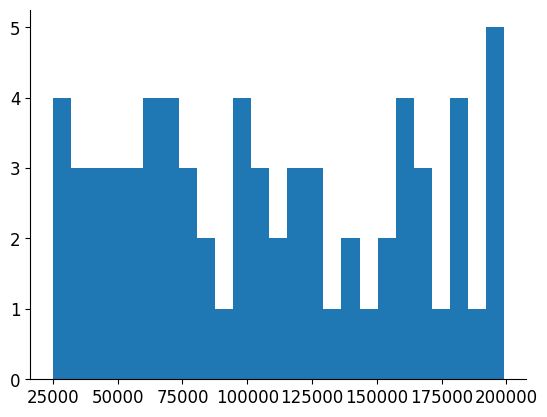

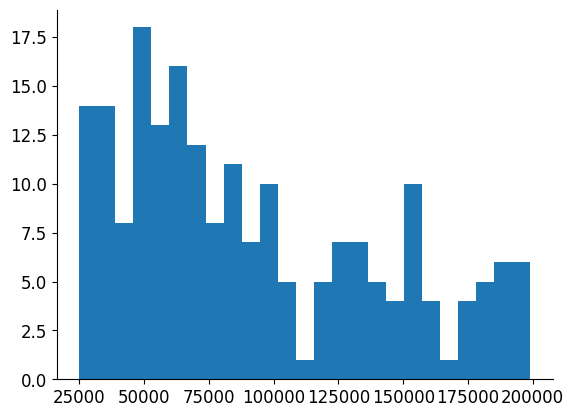

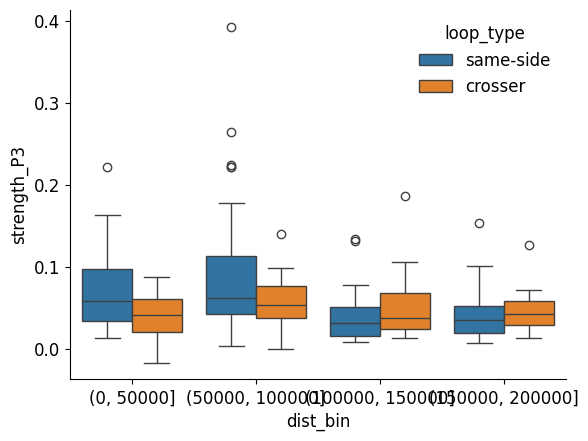

1.0


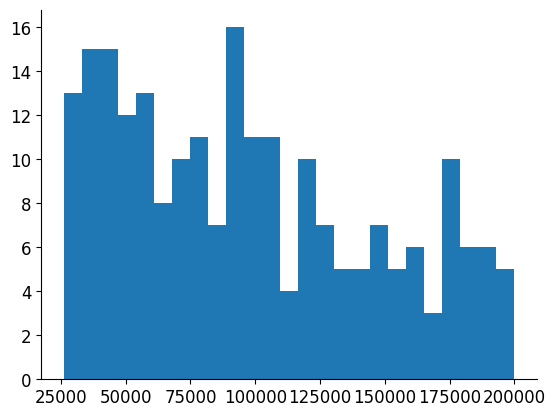

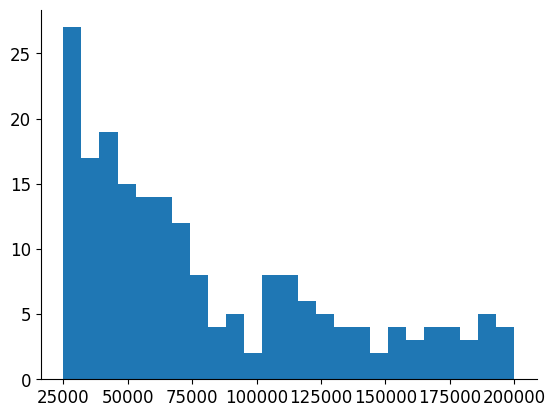

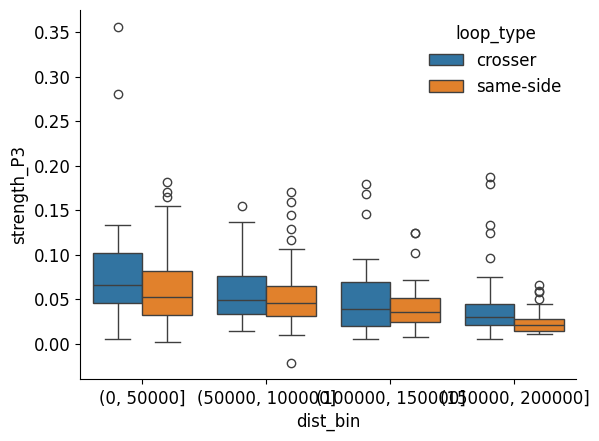

2.0


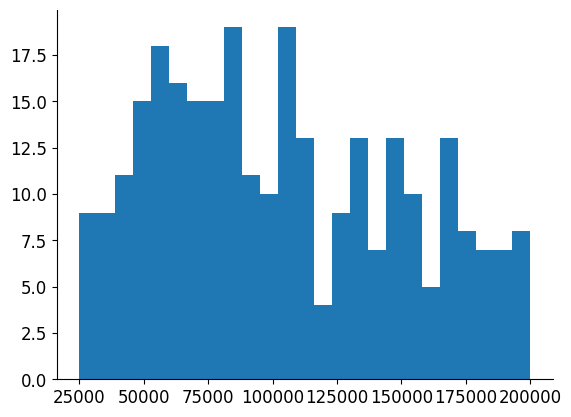

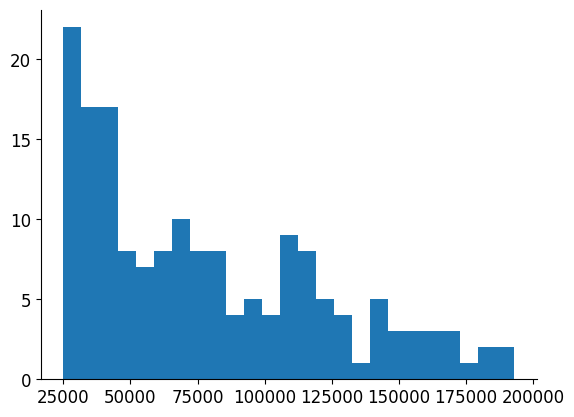

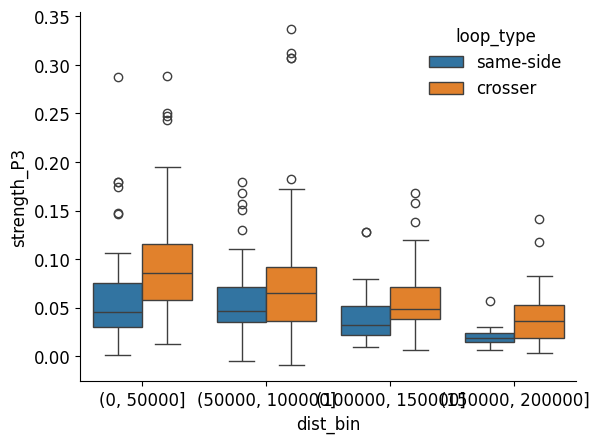

3.0


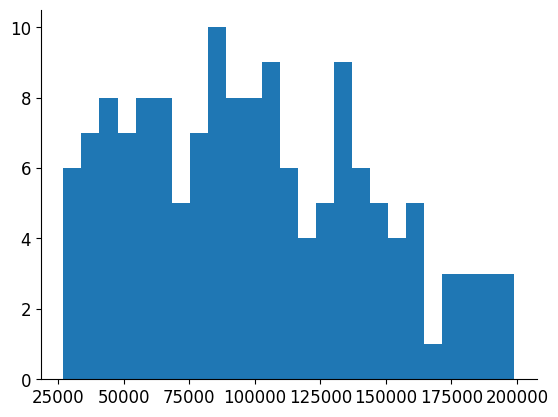

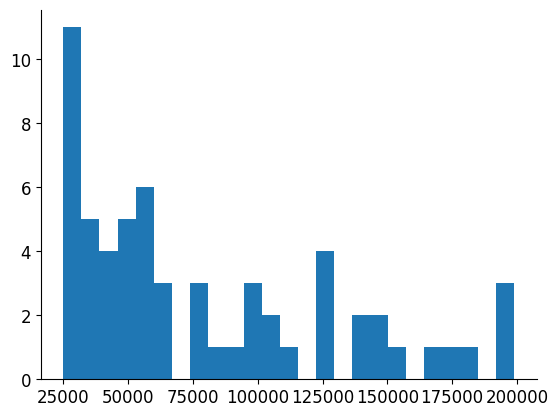

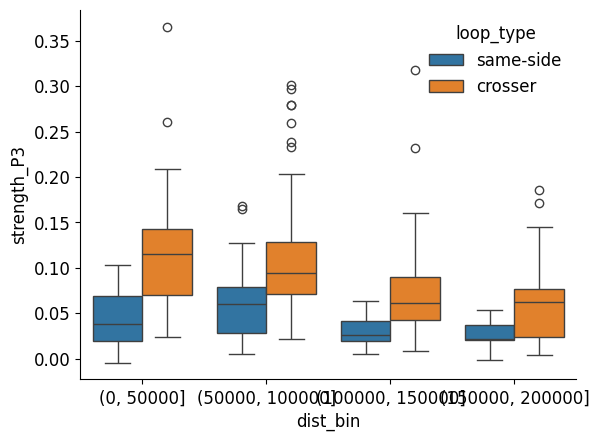

In [61]:
# on average, ss loops are shorter than crosser loops, but without distribution sampling 
# i can't make these distributions match. if anything, this reduces the stat power 
# of comparing crosser to SS loops

for q in np.sort(pls_mm['mm_quant'].dropna().unique()):
    print(q)
    pls_sub = pls_mm[pls_mm['mm_quant']==q]
    
    plt.hist(pls_sub[pls_sub['loop_type']=='crosser']['loop_span'], bins=25)
    #plt.savefig(os.path.join(savedir, f"{dataset_name}_quant{q}_crosser_distance_hist.svg"))

    plt.show()
    
    plt.hist(pls_sub[pls_sub['loop_type']=='same-side']['loop_span'], bins=25)
    #plt.savefig(os.path.join(savedir, f"{dataset_name}_quant{q}_ss_distance_hist.svg"))

    plt.show()
    
    bins = np.arange(0, 225_000, 50_000)
    pls_sub["dist_bin"] = pd.cut(pls_sub["loop_span"], bins)

    sns.boxplot(
        data=pls_sub,
        x="dist_bin",
        y="strength_P3",
        hue="loop_type",
    )
    plt.show()
    

In [62]:
paul_tol_four = ['#0077BB', '#33BBee', '#EE7733', '#CC3311']

MannwhitneyuResult(statistic=57100.0, pvalue=0.6466407618471015)
MannwhitneyuResult(statistic=64840.5, pvalue=4.507883411216903e-12)


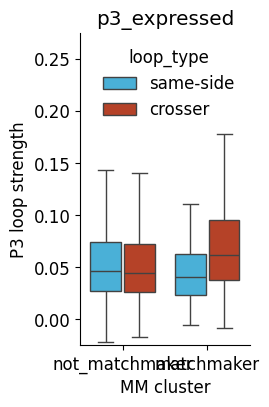

In [63]:
phase = "P3" 
fig, ax = plt.subplots(figsize=(3, 4))
sns.boxplot(
        data=pls_mm,
        x="mm_annotation",
        y=f"strength_{phase}",
        hue="loop_type",
        showfliers=False,
        palette=["#33BBEE","#CC3311"],
        gap=0.1,
        #order = ['not_matchmaker','matchmaker'],
        hue_order = ['same-side', 'crosser']
    )

print(mannwhitneyu(pls_mm[(pls_mm['loop_type']=='crosser')&(pls_mm['mm_quant'].isin([0,1]))]['strength_P3'].dropna(), 
                                   pls_mm[(pls_mm['loop_type']=='same-side')&(pls_mm['mm_quant'].isin([0,1]))]['strength_P3'].dropna()))
print(mannwhitneyu(pls_mm[(pls_mm['loop_type']=='crosser')&(pls_mm['mm_quant'].isin([2,3]))]['strength_P3'].dropna(), 
                                   pls_mm[(pls_mm['loop_type']=='same-side')&(pls_mm['mm_quant'].isin([2,3]))]['strength_P3'].dropna()))
plt.xlabel("MM cluster")
plt.ylabel(f"{phase} loop strength")
plt.tight_layout()
plt.title(dataset_name)
plt.ylim([-0.025, 0.275])
#plt.savefig(os.path.join(savedir, f"{dataset_name}_strengths_by_quant.svg"))

plt.show()

0.0


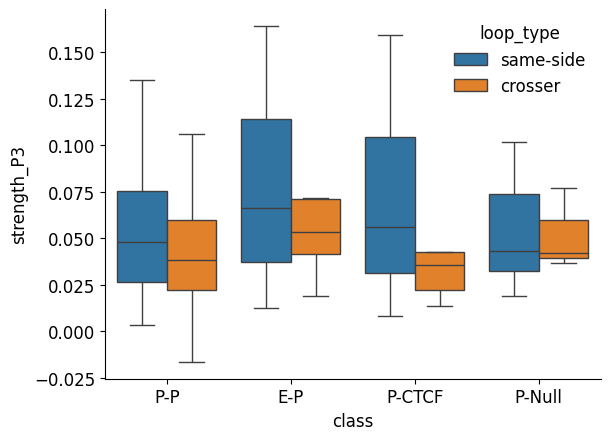

1.0


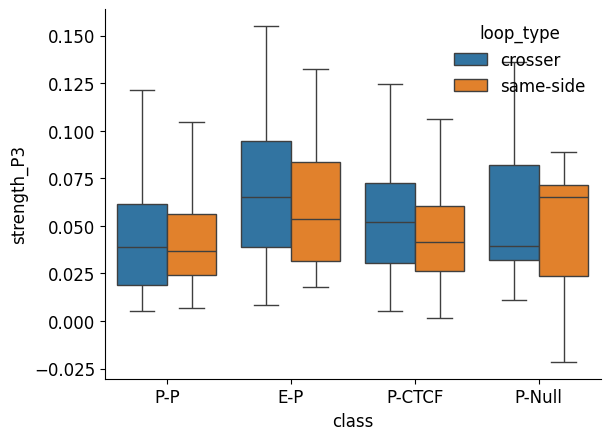

2.0


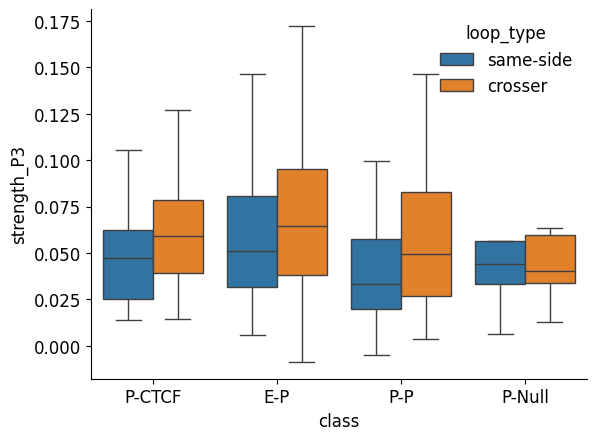

3.0


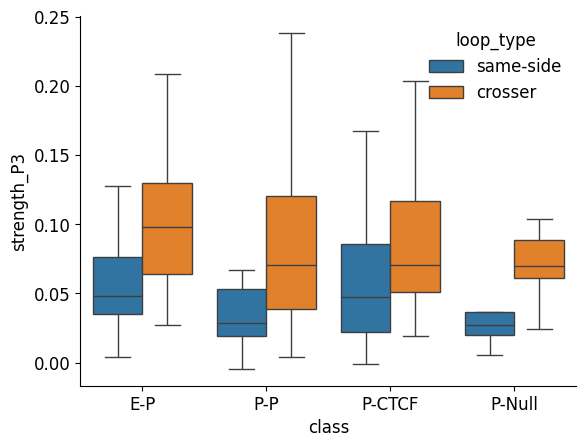

In [45]:
for q in np.sort(pls_mm['mm_quant'].dropna().unique()):
    print(q)
    pls_sub = pls_mm[(pls_mm['mm_quant']==q) &
                    (pls_mm['class'].isin(['E-P','P-P','P-CTCF','P-Null']))]

    sns.boxplot(
        data=pls_sub,
        x="class",
        y="strength_P3",
        hue="loop_type",
        showfliers=False
    )
    plt.show()
    

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


E-E
loop_type  mm_quant
crosser    2.0         1
same-side  0.0         4
           1.0         1
           2.0         1
           3.0         2
dtype: int64


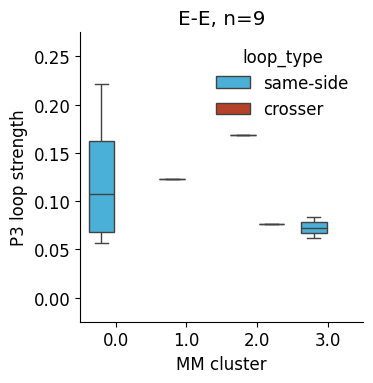

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


0
4
P-P
loop_type  mm_quant
crosser    0.0          39
           1.0          91
           2.0         108
           3.0          48
same-side  0.0         115
           1.0         116
           2.0          83
           3.0          21
dtype: int64


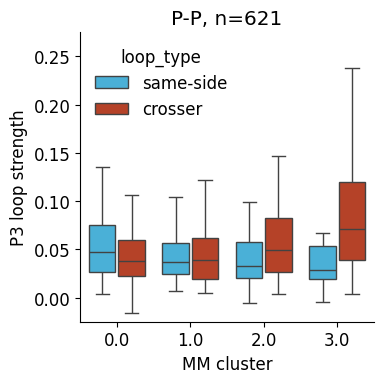

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


39
115
MannwhitneyuResult(statistic=1935.0, pvalue=0.20212302156082385)
91
116
MannwhitneyuResult(statistic=5000.5, pvalue=0.5172566236045448)
108
83
MannwhitneyuResult(statistic=5467.0, pvalue=0.009333041547014793)
48
21
MannwhitneyuResult(statistic=806.0, pvalue=8.420109131414192e-05)
E-P
loop_type  mm_quant
crosser    0.0         16
           1.0         65
           2.0         98
           3.0         47
same-side  0.0         35
           1.0         42
           2.0         46
           3.0         15
dtype: int64


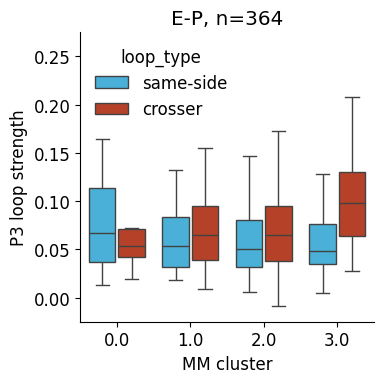

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


16
35
MannwhitneyuResult(statistic=251.0, pvalue=0.5628584981433917)
65
42
MannwhitneyuResult(statistic=1484.0, pvalue=0.4496499316712238)
98
46
MannwhitneyuResult(statistic=2643.0, pvalue=0.09599312719168987)
47
15
MannwhitneyuResult(statistic=543.0, pvalue=0.0017893753267944552)
P-CTCF
loop_type  mm_quant
crosser    0.0          9
           1.0         42
           2.0         52
           3.0         33
same-side  0.0         38
           1.0         33
           2.0         27
           3.0         13
dtype: int64


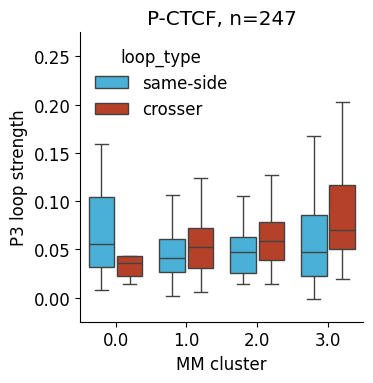

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


9
38
MannwhitneyuResult(statistic=110.0, pvalue=0.10184604484344696)
42
33
MannwhitneyuResult(statistic=818.0, pvalue=0.18389254612901373)
52
27
MannwhitneyuResult(statistic=859.0, pvalue=0.10573609732483431)
33
13
MannwhitneyuResult(statistic=296.0, pvalue=0.04814904369054936)
P-Null
loop_type  mm_quant
crosser    0.0          3
           1.0         23
           2.0         22
           3.0         19
same-side  0.0          9
           1.0          8
           2.0          9
           3.0          9
dtype: int64


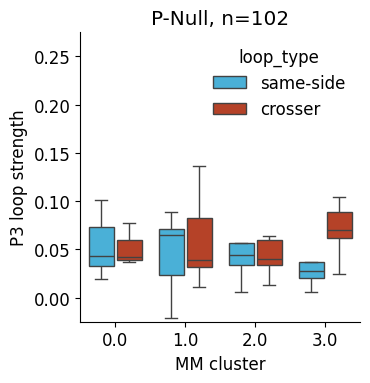

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


3
9
MannwhitneyuResult(statistic=14.0, pvalue=1.0)
23
8
MannwhitneyuResult(statistic=95.0, pvalue=0.911982861615787)
22
9
MannwhitneyuResult(statistic=97.0, pvalue=0.690098862383155)
19
9
MannwhitneyuResult(statistic=144.0, pvalue=0.004323773730325707)
CTCF-Null
loop_type  mm_quant
crosser    0.0         1
           3.0         1
dtype: int64


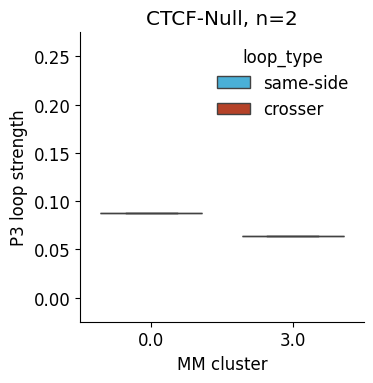

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


1
0
E-CTCF
loop_type  mm_quant
crosser    0.0         1
           2.0         3
same-side  2.0         1
dtype: int64


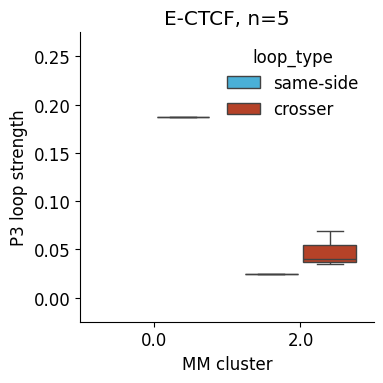

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


1
0
CTCF-CTCF
loop_type  mm_quant
same-side  1.0         1
dtype: int64


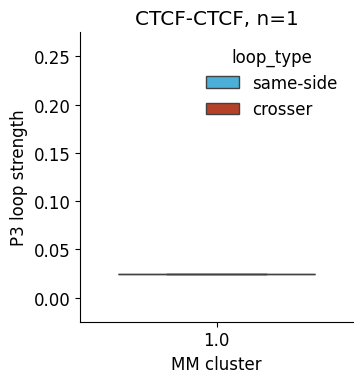

0
0


In [49]:

for loopclass in pls_mm['class'].unique():
    print(loopclass)

    datasub = pls_mm[pls_mm['class']==loopclass]
    phase = "P3"  # or P2, P3
    try:
        plt.figure(figsize=(4, 4))
        sns.boxplot(
            data=datasub,
            x="mm_quant",
            y=f"strength_{phase}",
            hue="loop_type",
            showfliers=False,
            palette=["#33BBEE",'#CC3311'],
            gap=0.1,
            #hue_order = ['not_matchmaker','matchmaker'],
            hue_order = ['same-side', 'crosser']
        )
        print(datasub.groupby(['loop_type', 'mm_quant']).agg('size'))
        plt.xlabel("MM cluster")
        ax.set_xticks(ticks=[0, 1, 2, 3], labels=range(1,5))
        plt.ylabel(f"{phase} loop strength")
        plt.title(f"{loopclass}, n={len(datasub)}")
            
        plt.tight_layout()
        plt.ylim([-0.025, 0.275])
        #plt.savefig(os.path.join(savedir, f"{dataset_name}_{loopclass}_strengths_by_quant.svg"))
        
        plt.show()
        
        for q in range(4):
            print(len(datasub[(datasub['loop_type']=='crosser')&(datasub['mm_quant']==q)]))
            print(len(datasub[(datasub['loop_type']=='same-side')&(datasub['mm_quant']==q)]))
            print(mannwhitneyu(datasub[(datasub['loop_type']=='crosser')&(datasub['mm_quant']==q)]['strength_P3'].dropna(), 
                                datasub[(datasub['loop_type']=='same-side')&(datasub['mm_quant']==q)]['strength_P3'].dropna()))

        #print(mannwhitneyu(datasub[(datasub['loop_type']=='crosser')&(datasub['mm_quant']==3)]['strength_P3'], 
         #                          datasub[(datasub['loop_type']=='crosser')&(datasub['mm_quant']==0)]['strength_P3']))
    except: 
        continue

In [482]:
# option 2: do contact frequency matching by creating X kb (maybe 3 or 5)? around promoter and then drawing the stripe from it